In [1]:
%%html
<style>@import url('style.css')</style><script>IPython.OutputArea.prototype._should_scroll = function(){return false}</script>

In [2]:
%run -i '_DataFrame-CSS.ipynb'
IPython.display.HTML(_df_style)

In [3]:
%env THEANO_FLAGS=floatX=float32,device=gpu0

env: THEANO_FLAGS=floatX=float32,device=gpu0


---
### Experiment settings

In [4]:
IMPORT_PATH = '_Datasets/'
%run -i '_Datasets/ESC-10.ipynb'

ESC-10 dataset loaded.


In [5]:
NET_WINDOW_SIZE = 'short'  # 'long' or 'short'
NET_MODE = 'majority'     # 'majority' or 'probability'

IMPORT_PATH = '_Networks/'
%run -i '_Networks/Net-DoubleConv.ipynb'

Using gpu device 0: Quadro P5000 (CNMeM is disabled, cuDNN 5105)
/usr/local/lib/python2.7/dist-packages/theano/sandbox/cuda/__init__.py:600: UserWarning: Your cuDNN version is more recent than the one Theano officially supports. If you see any problems, try updating Theano or downgrading cuDNN to version 5.
  warnings.warn(warn)


---

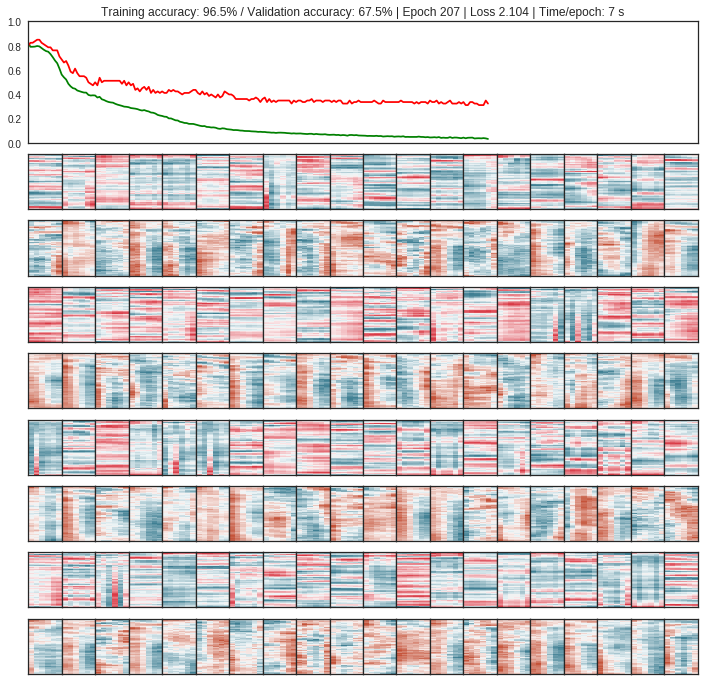

In [ ]:
for fold in ((5, 1), (1, 2), (2, 3), (3, 4), (4, 5)):
    VALIDATION_FOLD = fold[0]
    TESTING_FOLD = fold[1]
    
    if NET_WINDOW_SIZE == 'long':
        dataset_shape = (-1, 60, 101, 1)
        epochs = 150
        learning_rate = 0.01
    else:
        dataset_shape = (-1, 60, 41, 1)
        epochs = 300
        learning_rate = 0.002
    
    dataset = Dataset(esc10_features, fold_testing=TESTING_FOLD, fold_validation=VALIDATION_FOLD, shape=dataset_shape)
    model = learn_network(plot_filename='Results/ESC-10-' + NET_WINDOW_SIZE + '-' + NET_MODE + '-Fold_' + str(TESTING_FOLD),
                          epochs=epochs, learning_rate=learning_rate)
    
    conf_matrix, aggregated = evaluate_model(dataset, model, TESTING_FOLD, 'Results/ESC-10-' + NET_WINDOW_SIZE + '-' + NET_MODE + '-Fold_' + str(TESTING_FOLD) + '.txt')
    
    with open('_Models/ESC-10-' + NET_WINDOW_SIZE + '-' + NET_MODE + '-Fold_' + str(TESTING_FOLD) + '_model.pkl', 'wb') as f: cPickle.dump(model, f, 2)
    with open('_Models/ESC-10-' + NET_WINDOW_SIZE + '-' + NET_MODE + '-Fold_' + str(TESTING_FOLD) + '_conf.pkl', 'wb') as f: cPickle.dump(conf_matrix, f, 2)    
    with open('_Models/ESC-10-' + NET_WINDOW_SIZE + '-' + NET_MODE + '-Fold_' + str(TESTING_FOLD) + '_agg.pkl', 'wb') as f: cPickle.dump(aggregated, f, 2)            